In [14]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from src.dataset import CastingDataset
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader

ds = CastingDataset(root_dir="../data/processed/test")
print(len(ds))

651


In [15]:
img, label = ds[0]
print(type(img), label)

<class 'PIL.Image.Image'> 1


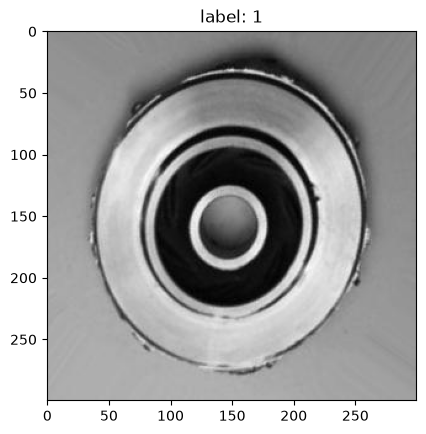

In [16]:
plt.imshow(img)
plt.title(f"label: {label}")
plt.show()

In [17]:
weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [18]:
ds = CastingDataset(root_dir="../data/processed/test", transform=preprocess)
img, label = ds[0]
print(type(img), img.shape, img.dtype)

<class 'torch.Tensor'> torch.Size([3, 224, 224]) torch.float32


In [19]:
loader = DataLoader(ds, batch_size=16, shuffle=True)

In [20]:
images, labels = next(iter(loader))
print(images.shape, labels.shape)

torch.Size([16, 3, 224, 224]) torch.Size([16])


In [21]:
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/borhan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 37.0MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta